# 02 平地で静止（EqualShare + MapJT）

## 背景

01 までで、トルクは飽和してプラントに入る。まだ体重の分け方が無い。

脚力は EqualShare（$F_z=mg/4$、$F_x=F_y=0$）。仮想仕事は $\tau_{\mathrm{map}}=-J^{\top}F$。00 の運動方程式で $\ddot q\approx 0$ なら関節は $\tau=h-J^{\top}F$ である。$h$ は重力とコリオリ（`qfrc_bias`）であり、キーフレームの関節 PD ではない。

試行 2 は $-J^{\top}F$ だけ。失敗ログと GIF は消さない。

### 成功条件（数値。ここが合否）

[README §3.8](../docs/block-curriculum/00_README.md) / [S1](../docs/block-curriculum/02_Stage_Ladder.md)。**連続 5.0 秒以上、全ステップ。** 一瞬の通過は失敗。

| 量 | 条件 |
|---|---|
| ベース高さ | $\lvert z(t)-z_0\rvert < 0.03\,\mathrm{m}$ |
| 姿勢 | $\lvert\mathrm{roll}\rvert<0.10\,\mathrm{rad}$、$\lvert\mathrm{pitch}\rvert<0.10\,\mathrm{rad}$ |
| 並進速度 | $\lVert v\rVert < 0.15\,\mathrm{m/s}$ |
| `qpos` | すべて有限 |
| 連続時間 | $\mathrm{d}t\times$（連続 True の最長） $\ge 5.0\,\mathrm{s}$ |
| 結果 GIF | 1 本以上（指令 GRF と実接触）。失敗走行の GIF も残す |

キーフレームへ戻す関節 PD は使わない。満たすまで 03 へ進まない。

## 目的

- EqualShare と MapJT（$-J^{\top}F$）をセルに出し、手計算と突き合わせる
- 静止に $h$ が要るかを、同じ成功条件の秒数で比較する
- 平地で 5 秒以上ほぼ静止する

## 数式

$$
c=(1,1,1,1),\quad F_{z,i}=\frac{mg}{4},\quad F_{x,i}=F_{y,i}=0
$$

$$
\tau_{\mathrm{map}} = -J^{\top} F, \qquad \tau = h - J^{\top} F \quad (\ddot q \approx 0)
$$

## 図

```
EqualShare --> Grf (4,3)
                 |
            map_jt  -J^T F
                 |  (+ h  in trial 3)
                 v
               clip --> MuJoCo
```

## 思考過程

後脚が畳んで見える、thigh の $\tau\approx 0$、符号、配線を疑う。そのあと、00 の式に $h$ があるのに指令から落としている可能性を疑う。

## 仮説

1. $J$ が嘘、または後脚に $\tau$ が入っていない
2. $J$ は正しいが $-J^{\top}F$ だけでは $h$ が残り、ピッチする
3. 同じ EqualShare で $\tau=h-J^{\top}F$ なら、背景の数値を 5 秒以上満たす


In [1]:
from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

# 背景の成功条件。変えたら上の表も更新する。
HOLD_S = 5.0
Z_TOL = 0.03       # m
ATT_TOL = 0.10     # rad
V_TOL = 0.15       # m/s

def longest_true_seconds(flags, dt):
    """連続 True の最長 [s]。1 ステップだけ True ならほぼ dt。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def stand_ok(z0, plant):
    z = float(plant.base_pos()[2])
    roll, pitch, _ = plant.base_rpy()
    v = float(np.linalg.norm(plant.base_lin_vel_world()))
    return (
        abs(z - z0) < Z_TOL
        and abs(roll) < ATT_TOL
        and abs(pitch) < ATT_TOL
        and v < V_TOL
        and bool(np.isfinite(plant.data.qpos).all())
    )

# ctrl の並びは XML どおり FL, FR, RL, RR × hip, thigh, calf。後脚が末尾 6。
ACT = [
    "FL_hip","FL_thigh","FL_calf",
    "FR_hip","FR_thigh","FR_calf",
    "RL_hip","RL_thigh","RL_calf",
    "RR_hip","RR_thigh","RR_calf",
]
LEGS = ("FL","FR","RL","RR")

def clip_torque(tau, ctrl_range):
    """出せないトルクを捨てる。静止の合否とは別。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def equal_share(mass_kg, n_stance=4):
    """README の脚力: 立脚で mg を等分。横力 0。ホライズン無し。"""
    fz = mass_kg * 9.81 / n_stance
    grf = np.zeros((4, 3))
    grf[:, 2] = fz
    return grf

def foot_jac(model, data, geom_id):
    """足 geom の並進ヤコビ (3, nv)、world。列 0-5 が浮遊ベース、以降が関節。"""
    jacp = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, jacp, None, int(geom_id))
    return jacp

def map_jt(model, data, geom_ids, grf):
    """仮想仕事 tau_map = -J^T F。F は床から足。ここでは h を足さない。"""
    tau_full = np.zeros(model.nv)
    for geom_id, force in zip(geom_ids, grf):
        J = foot_jac(model, data, geom_id)
        tau_full -= J.T @ force
    return tau_full[-model.nu:]

def map_jt_plus_h(model, data, geom_ids, grf):
    """00 の式で qdd=0: tau = h - J^T F。h=qfrc_bias。関節 PD ではない。"""
    h = np.asarray(data.qfrc_bias[-model.nu:], dtype=np.float64)
    return h + map_jt(model, data, geom_ids, grf)

plant = MujocoGo2(scene="flat", seed=0)
m, d = plant.model, plant.data
dt = plant.sim_dt
n_steps = int(np.ceil(HOLD_S / dt)) + int(round(0.5 / dt))  # 5.5 s
geoms = plant.foot_geom_ids()
cmd = equal_share(plant.mass_kg, 4)
print("mass", plant.mass_kg, "mg", plant.mass_kg * 9.81, "Fz each", cmd[0, 2])
print("dt", dt, "n_steps", n_steps, "T_plan", n_steps * dt)
print("geom names", [m.geom(int(g)).name for g in geoms])
print("actuator names", [m.actuator(i).name for i in range(m.nu)])


mass 15.206408000000003 mg 149.17486248000003 Fz each 37.29371562000001
dt 0.002 n_steps 2750 T_plan 5.5
geom names ['FL', 'FR', 'RL', 'RR']
actuator names ['FL_hip', 'FL_thigh', 'FL_calf', 'FR_hip', 'FR_thigh', 'FR_calf', 'RL_hip', 'RL_thigh', 'RL_calf', 'RR_hip', 'RR_thigh', 'RR_calf']


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## 試行 1 — $J$ の中身と有限差分

仮説: thigh の $\tau\approx 0$ は実装バグではなく、$J_{z,\mathrm{thigh}}$ が本当に小さい。有限差分 $\Delta p_z/\Delta q_{\mathrm{thigh}}$ と `mj_jacGeom` を比べる。


In [2]:
np.set_printoptions(precision=4, suppress=True)
print("--- J_trans (world) columns of the 3 joints of each foot; rows = x,y,z ---")
for i, leg in enumerate(LEGS):
    J = foot_jac(m, d, geoms[i])
    cols = 6 + 3*i  # 浮遊ベース 6 のあと、脚ごとに 3 関節
    Jleg = J[:, cols:cols+3]
    print(leg, "J (3x3 hip,thigh,calf)")
    print(Jleg)
    # EqualShare は Fz だけなので、tau は -Jz * Fz。ここを手計算と照らす。
    print("  Jz (row z):", Jleg[2], "=> tau from Fz only =", -Jleg[2]*cmd[0,2])

# J が嘘でないか: FL_thigh を微小に動かして足位置の差分を取る。
# qpos[8] は FL_thigh（freejoint 7 + hip）。qvel 列は 7。
qpos0 = d.qpos.copy()
eps = 1e-5
gid = int(geoms[0])
mujoco.mj_forward(m, d)
p0 = d.geom_xpos[gid].copy()
d.qpos[8] += eps
mujoco.mj_forward(m, d)
p1 = d.geom_xpos[gid].copy()
d.qpos[:] = qpos0
mujoco.mj_forward(m, d)
fd = (p1 - p0) / eps
J = foot_jac(m, d, geoms[0])
print("FL foot finite-diff dp/d(FL_thigh)", fd)
print("FL foot mj_jacGeom col thigh     ", J[:, 7])
print("max |fd - jac|", np.max(np.abs(fd - J[:, 7])))


--- J_trans (world) columns of the 3 joints of each foot; rows = x,y,z ---
FL J (3x3 hip,thigh,calf)
[[ 0.     -0.2664 -0.134 ]
 [ 0.2664  0.      0.    ]
 [ 0.0955  0.0012 -0.1656]]
  Jz (row z): [ 0.0955  0.0012 -0.1656] => tau from Fz only = [-3.5615 -0.0464  6.176 ]
FR J (3x3 hip,thigh,calf)
[[ 0.     -0.2664 -0.134 ]
 [ 0.2664  0.      0.    ]
 [-0.0955  0.0012 -0.1656]]
  Jz (row z): [-0.0955  0.0012 -0.1656] => tau from Fz only = [ 3.5615 -0.0464  6.176 ]
RL J (3x3 hip,thigh,calf)
[[ 0.     -0.2664 -0.134 ]
 [ 0.2664  0.      0.    ]
 [ 0.0955  0.0012 -0.1656]]
  Jz (row z): [ 0.0955  0.0012 -0.1656] => tau from Fz only = [-3.5615 -0.0464  6.176 ]
RR J (3x3 hip,thigh,calf)
[[ 0.     -0.2664 -0.134 ]
 [ 0.2664  0.      0.    ]
 [-0.0955  0.0012 -0.1656]]
  Jz (row z): [-0.0955  0.0012 -0.1656] => tau from Fz only = [ 3.5615 -0.0464  6.176 ]
FL foot finite-diff dp/d(FL_thigh) [-0.2664  0.      0.0012]
FL foot mj_jacGeom col thigh      [-0.2664 -0.      0.0012]
max |fd - jac| 1.331

## 試行 2 — $\tau=-J^{\top}F$ を 12 関節に載せる

仮説: 後脚にも同じ式で非ゼロの $\tau$ が入る。GIF キャプションに RL/RR の $\tau$ を出す（矢印は GRF であり関節トルクではない）。


In [3]:
tau0 = map_jt(m, d, geoms, cmd)
print("tau = -J^T F at t=0  (後脚は RL_* / RR_*。ゼロなら配線ミス)")
for name, val in zip(ACT, tau0):
    print(f"  {name:10s} {val:8.3f} N·m")
# 後脚 hip に数 N·m あることだけ確認。これで「静止した」ことにはならない。
print("rear hip tau RL, RR =", tau0[6], tau0[9])


tau = -J^T F at t=0  (後脚は RL_* / RR_*。ゼロなら配線ミス)
  FL_hip       -3.562 N·m
  FL_thigh     -0.046 N·m
  FL_calf       6.176 N·m
  FR_hip        3.562 N·m
  FR_thigh     -0.046 N·m
  FR_calf       6.176 N·m
  RL_hip       -3.562 N·m
  RL_thigh     -0.046 N·m
  RL_calf       6.176 N·m
  RR_hip        3.562 N·m
  RR_thigh     -0.046 N·m
  RR_calf       6.176 N·m
rear hip tau RL, RR = -3.561549841710001 3.561549841710001


trial2 -J^T F  t_end 5.501999999999616 hold_stand_s 0.786
z0,zT,zmin 0.2901090289418327 0.25478989266400454 0.2540751709356629 pitch maxabs 0.8438775874805814
trial2 FAIL expected: True


/home/takuya/work/mpc_dog/notebook/assets/02a_mapjt_equalshare.gif 2074785 bytes


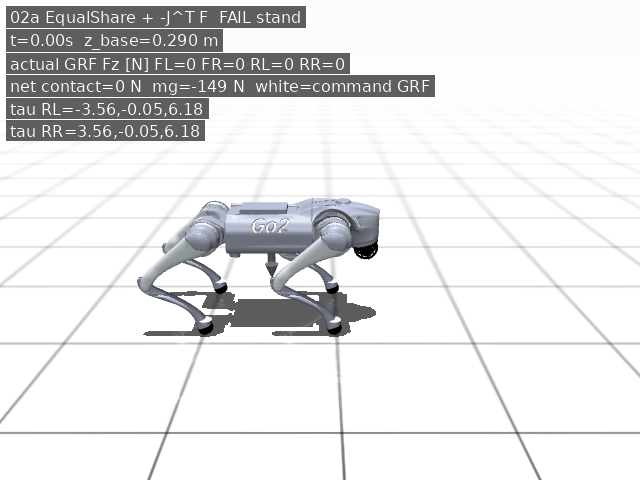

In [4]:
# 試行 2 の結果 GIF（失敗も必須）。白=指令 GRF、色=実接触。
# 同じ 5.5 s ログで、背景の静止条件が何秒続くかを数値で見る（一瞬合格にしない）。
plant = MujocoGo2(scene="flat", seed=0)
geoms = plant.foot_geom_ids()
cmd = equal_share(plant.mass_kg, 4)
z0 = float(plant.base_pos()[2])
ok, zs, pitches = [], [], []

def tau_map_only(p):
    # 毎周期 J を取り直す。この試行は -J^T F だけ。h も PD も足さない。
    return clip_torque(map_jt(p.model, p.data, geoms, cmd), p.model.actuator_ctrlrange)

p_eval = MujocoGo2(scene="flat", seed=0)
z0 = float(p_eval.base_pos()[2])
for _ in range(n_steps):
    p_eval.step(tau_map_only(p_eval))
    ok.append(stand_ok(z0, p_eval))
    zs.append(float(p_eval.base_pos()[2]))
    pitches.append(float(p_eval.base_rpy()[1]))
hold = longest_true_seconds(ok, dt)
zs, pitches = np.asarray(zs), np.asarray(pitches)
print("trial2 -J^T F  t_end", float(p_eval.data.time), "hold_stand_s", hold)
print("z0,zT,zmin", zs[0], zs[-1], zs.min(), "pitch maxabs", np.max(np.abs(pitches)))
print("trial2 FAIL expected:" , hold < HOLD_S)

plant = MujocoGo2(scene="flat", seed=0)
gif = Path("assets/02a_mapjt_equalshare.gif")
path = render_rollout_gif(
    plant, gif, n_steps=n_steps, capture_every=60, tau_fn=tau_map_only, command_grf=cmd,
    extra_lines=lambda p: [
        f"tau RL={p.data.ctrl[6]:.2f},{p.data.ctrl[7]:.2f},{p.data.ctrl[8]:.2f}",
        f"tau RR={p.data.ctrl[9]:.2f},{p.data.ctrl[10]:.2f},{p.data.ctrl[11]:.2f}",
    ],
    title="02a EqualShare + -J^T F  FAIL stand",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析（試行 2 のあと）

失敗 GIF を残す。合否は背景の表である。$-J^{\top}F$ だけでは **連続 5.0 s の静止に届かない**（ピッチが 0.1 rad を超える）。

- 有限差分と `mj_jacGeom` が一致し、後脚 $\tau$ が非ゼロなら、「後脚に入れていなかった」は誤り
- ここでキーフレーム PD を足して立ったことにしない
- 次の仮説: 00 の $h$ を落としている


## 試行 1–2 の結果（消さない）

有限差分と `mj_jacGeom` は一致した（$10^{-6}$）。「$J$ が嘘」ではない。

FL の thigh 列（world）:

$$
\frac{\partial p}{\partial q_{\mathrm{thigh}}} \approx (-0.266,\; 0,\; 0.0012)
$$

thigh を動かすと足は前後（$x$）に動き、高さ $z$ はほとんど変わらない。EqualShare は $F=(0,0,F_z)$ なので $\tau_{\mathrm{thigh}}\approx -0.05\,\mathrm{N\cdot m}$。

鉛直合力は体重近くまで出るが、ピッチが増えて背景の 5 秒静止には失敗する。


In [5]:
# 参考: 同じ姿勢の qfrc_bias（関節の重力+コリオリ = h）。
# 試行 2 では tau に足していない。大きさを見て、次の仮説（足す）の根拠にする。
plant_b = MujocoGo2(scene="flat", seed=0)
mujoco.mj_forward(plant_b.model, plant_b.data)
bias = np.asarray(plant_b.data.qfrc_bias[6:], dtype=float)
tau_m = map_jt(plant_b.model, plant_b.data, plant_b.foot_geom_ids(), equal_share(plant_b.mass_kg, 4))
print("qfrc_bias joints vs mapjt (trial 2 did not add h)")
for name, b, t in zip(ACT, bias, tau_m):
    print(f"  {name:10s}  h={b:7.3f}  mapjt={t:7.3f}  N·m")


qfrc_bias joints vs mapjt (trial 2 did not add h)
  FL_hip      h=  1.065  mapjt= -3.562  N·m
  FL_thigh    h=  0.439  mapjt= -0.046  N·m
  FL_calf     h= -0.272  mapjt=  6.176  N·m
  FR_hip      h= -1.065  mapjt=  3.562  N·m
  FR_thigh    h=  0.439  mapjt= -0.046  N·m
  FR_calf     h= -0.272  mapjt=  6.176  N·m
  RL_hip      h=  1.065  mapjt= -3.562  N·m
  RL_thigh    h=  0.439  mapjt= -0.046  N·m
  RL_calf     h= -0.272  mapjt=  6.176  N·m
  RR_hip      h= -1.065  mapjt=  3.562  N·m
  RR_thigh    h=  0.439  mapjt= -0.046  N·m
  RR_calf     h= -0.272  mapjt=  6.176  N·m


## 試行 3 — $\tau = h - J^{\top}F$（仮説 3）

00 の式 $M\ddot q+h=S^{\top}\tau+J^{\top}\lambda$ で $\ddot q\approx 0$、$\lambda=F$（EqualShare）なら $\tau=h-J^{\top}F$。

$h$ は `qfrc_bias`。キーフレームの目標角度へ PD しない。脚力は試行 2 と同じ EqualShare。


trial3 h-J^T F  t_end 5.501999999999616 hold_stand_s 5.5
dz max 0.0010384496506857244 roll maxabs 0.0012948563554248367 pitch maxabs 0.0018054276433059346
v max 0.060425286662083286 v last1s mean 9.758259399512135e-05
netFz last 149.1748773792083 mg 149.17486248000003
02 PASS: stand held 5.5 s  (criteria in 背景)


/home/takuya/work/mpc_dog/notebook/assets/02b_h_mapjt_equalshare.gif 1964432 bytes


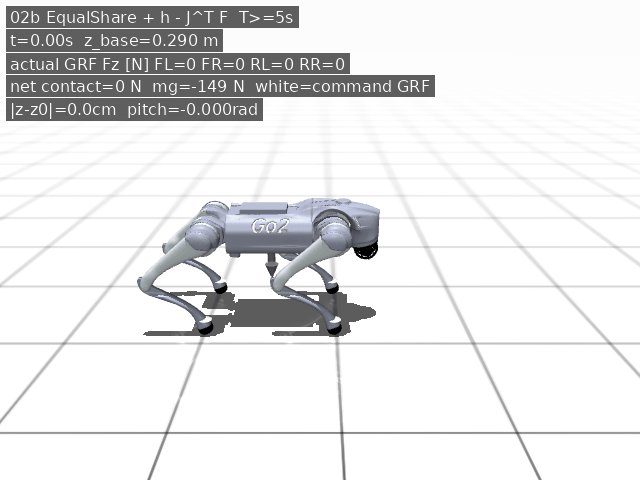

In [6]:
# 試行 3: 同じ EqualShare。tau = h - J^T F。関節 PD なし。
plant_e = MujocoGo2(scene="flat", seed=0)
geoms = plant_e.foot_geom_ids()
cmd = equal_share(plant_e.mass_kg, 4)
z0 = float(plant_e.base_pos()[2])

def tau_h_mapjt(p):
    u = map_jt_plus_h(p.model, p.data, geoms, cmd)
    return clip_torque(u, p.model.actuator_ctrlrange)

ok = []
zs, pitches, rolls, vn = [], [], [], []
for _ in range(n_steps):
    plant_e.step(tau_h_mapjt(plant_e))
    ok.append(stand_ok(z0, plant_e))
    zs.append(float(plant_e.base_pos()[2]))
    rpy = plant_e.base_rpy()
    rolls.append(float(rpy[0])); pitches.append(float(rpy[1]))
    vn.append(float(np.linalg.norm(plant_e.base_lin_vel_world())))

hold = longest_true_seconds(ok, dt)
zs, pitches, rolls, vn = map(np.asarray, (zs, pitches, rolls, vn))
print("trial3 h-J^T F  t_end", float(plant_e.data.time), "hold_stand_s", hold)
print("dz max", np.max(np.abs(zs - z0)), "roll maxabs", np.max(np.abs(rolls)), "pitch maxabs", np.max(np.abs(pitches)))
print("v max", vn.max(), "v last1s mean", vn[-int(1.0 / dt):].mean())
print("netFz last", plant_e.net_contact_force_world()[2], "mg", plant_e.mass_kg * 9.81)
assert hold >= HOLD_S, f"stand held {hold:.3f}s < {HOLD_S} (not instant)"
print("02 PASS: stand held", hold, "s  (criteria in 背景)")

plant = MujocoGo2(scene="flat", seed=0)
gif = Path("assets/02b_h_mapjt_equalshare.gif")
path = render_rollout_gif(
    plant, gif, n_steps=n_steps, capture_every=60, tau_fn=tau_h_mapjt, command_grf=cmd,
    extra_lines=lambda p: [
        f"|z-z0|={abs(p.base_pos()[2]-z0)*100:.1f}cm  pitch={p.base_rpy()[1]:.3f}rad",
    ],
    title="02b EqualShare + h - J^T F  T>=5s",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析（試行 3）

- 試行 2（$-J^{\top}F$ だけ）は背景の 5 秒静止に失敗する。GIF `02a` を残す
- 試行 3 は同じ EqualShare で $h$ を足した。キーフレーム PD ではない
- 合否は `hold_stand_s >= 5.0`。`02 PASS` が出てから 03 へ進む

## 次の仮説

力の和が $mg$ のままでは高さを指定できない。次は高さである。
